In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [31]:
# load the Dataset
data = load_breast_cancer()
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [32]:
# Separate features and target
X = df.drop(
    "target",
    axis=1
)

y = df["target"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [33]:
# Split the DataSet
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [34]:
# Scale the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)

In [35]:
# Create the SVM model
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

In [36]:
# train the SVM Model
svm_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [37]:
# Make Prediction
y_pred_svm = svm_model.predict(
    X_test_scaled
)
print("Predictions:")
print(y_pred_svm[:20])
print("Actual Values:")
print(y_test.values[:20])

Predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]
Actual Values:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


In [38]:
# calculate Accuracy
accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print(
    "SVM Accuracy:",
    accuracy_svm
)
print(
    "SVM Accuracy:",
    round(accuracy_svm * 100, 2),
    "%"
)

SVM Accuracy: 0.9824561403508771
SVM Accuracy: 98.25 %


In [39]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [40]:
# confusion matrix
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print("Confusion Matrix:")
print(cm_svm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


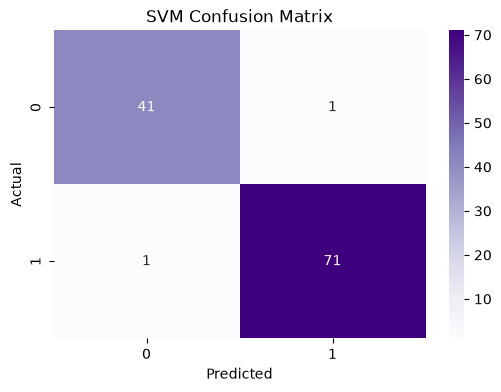

In [41]:
# visualize the confusion Matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "SVM Confusion Matrix"
)

plt.show()

In [42]:
# Experiment with different SVM Kernels
kernels = [
    "linear",
    "rbf",
    "poly",
    "sigmoid"
]

In [43]:
# Train Dand compare Different Kernels
kernel_results = []

for kernel in kernels:
    
    model = SVC(
        kernel=kernel,
        random_state=42
    )
    
    model.fit(
        X_train_scaled,
        y_train
    )
    
    predictions = model.predict(
        X_test_scaled
    )
    
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    kernel_results.append({
        "Kernel": kernel,
        "Accuracy": accuracy
    })

In [44]:
# display Kernel Comparison
kernel_results_df = pd.DataFrame(
    kernel_results
)
kernel_results_df

,Kernel,Accuracy
0,linear,0.973684
1,rbf,0.982456
2,poly,0.912281
3,sigmoid,0.929825


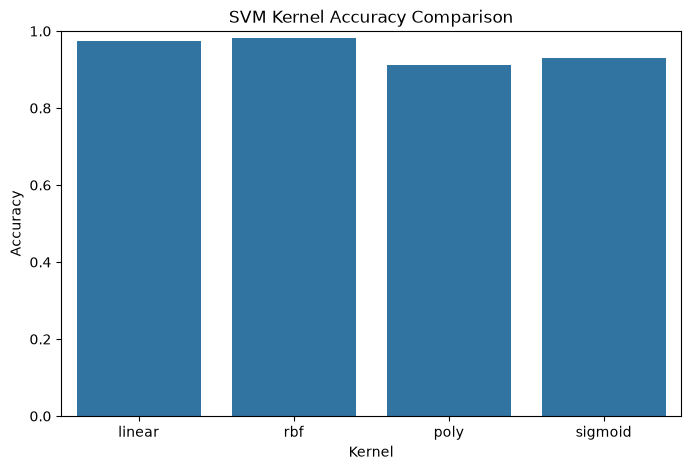

In [45]:
# visualize Kernel Performance
plt.figure(figsize=(8, 5))

sns.barplot(
    data=kernel_results_df,
    x="Kernel",
    y="Accuracy"
)

plt.title(
    "SVM Kernel Accuracy Comparison"
)

plt.xlabel("Kernel")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

In [46]:
# find the best SVM kernel
best_kernel_row = kernel_results_df.loc[
    kernel_results_df["Accuracy"].idxmax()
]

print(
    "Best Kernel:",
    best_kernel_row["Kernel"]
)

print(
    "Best Accuracy:",
    best_kernel_row["Accuracy"]
)
print(
    "Best Accuracy:",
    round(
        best_kernel_row["Accuracy"] * 100,
        2
    ),
    "%"
)

Best Kernel: rbf
Best Accuracy: 0.9824561403508771
Best Accuracy: 98.25 %


In [47]:
# train the final SVM model
best_kernel = best_kernel_row["Kernel"]
#create final model
best_svm_model = SVC(
    kernel=best_kernel,
    random_state=42
)
#train the model
best_svm_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [48]:
# final prediciton
best_svm_predictions = best_svm_model.predict(
    X_test_scaled
)

In [49]:
# Evaluate the Final SVM Model
best_svm_accuracy = accuracy_score(
    y_test,
    best_svm_predictions
)

print(
    "Final SVM Accuracy:",
    round(
        best_svm_accuracy * 100,
        2
    ),
    "%"
)
print(
    classification_report(
        y_test,
        best_svm_predictions
    )
)

Final SVM Accuracy: 98.25 %
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



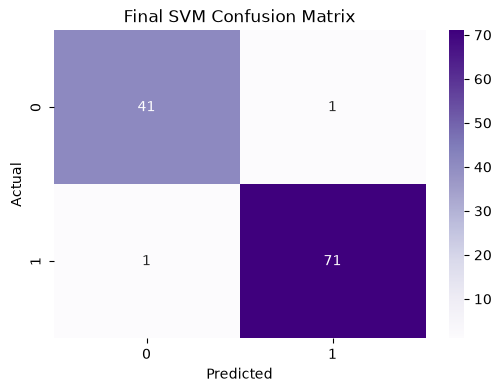

In [50]:
# Final confusion matrix
best_svm_cm = confusion_matrix(
    y_test,
    best_svm_predictions
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    best_svm_cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Final SVM Confusion Matrix"
)

plt.show()

In [51]:
# final SVM performance
print(
    "SVM Model Performance"
)

print(
    "---------------------"
)

print(
    "Best Kernel:",
    best_kernel
)

print(
    "Accuracy:",
    round(
        best_svm_accuracy,
        4
    )
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        best_svm_predictions
    )
)

print(
    "\nConfusion Matrix:"
)

print(
    best_svm_cm
)

SVM Model Performance
---------------------
Best Kernel: rbf
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[41  1]
 [ 1 71]]
